# SSRT Control Notebook For Controller Design
# Author: Benjamin Pele

In [108]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
import scipy as sp

In [109]:
# Setting up State Space Model

m = 60 # mass in kilograms
g = 9.81 # acceleration due to gravity, m/s^2
ta = 0.1598 #axial torque, kg * m
tr = ta # rotational torque, kg * m
fv = m*g # vertical force, N
fn = fv + m*g # normal force, N
jw = 0.21 # rotational inertia, kg * m^2
mu = 0.4 # kinetic coefficient of friction, unitless
ja = 6.434e-9 #moment of axial inertia, m^4
k = 3*0.11/0.05919 # spring constant, N/m


#state space matrices, x'(t) = A*x(t) + B, y(t) = C*x(t) + D possible measurements are vertical distance (y), 
# turn of motor (theta), turn of pole (alpha) and their time derivatives

A = np.array([[0, 1, 0, 0, 0, 0],
              [-k/m, 0, 0, 0, 0, 0],
              [0, 0, 0, 1, 0, 0],
              [0, 0, -k/jw, 0, 0, 0],
              [0, 0, 0, 0, 0, 1],
              [0, 0, 0, 0, -k/ja, 0]])

#B = np.array([0, (fv + mu*fn)/m, 0, tr/jw, 0, ta/ja])
B = np.array([[1/m], [0], [1/jw], [0], [1/ja], [0]])

C = np.array([1, 0, 1, 0, 0, 0]) #measuring turn of the motor

D = 0

P = ct.ss(A, B, C, D)

print('A matrix:\n', P.A)
print('\nB matrix:\n', P.B)
print('\nC matrix:\n', P.C)
print('\nD matrix:\n', P.D)

A matrix:
 [[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-9.29211015e-02  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -2.65488862e+01  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  -8.66531876e+08  0.00000000e+00]]

B matrix:
 [[1.66666667e-02]
 [0.00000000e+00]
 [4.76190476e+00]
 [0.00000000e+00]
 [1.55424308e+08]
 [0.00000000e+00]]

C matrix:
 [[1. 0. 1. 0. 0. 0.]]

D matrix:
 [[0.]]


In [110]:
# Controllability Matrix
controllability = ct.ctrb(P.A, P.B)
print('Controllability Matrix:\n', controllability)
print('\nRank of Controllability Matrix: ', np.linalg.matrix_rank(controllability))

Controllability Matrix:
 [[ 1.66666667e-02  0.00000000e+00 -1.54868503e-03  0.00000000e+00
   1.43905519e-04  0.00000000e+00]
 [ 0.00000000e+00 -1.54868503e-03  0.00000000e+00  1.43905519e-04
   0.00000000e+00 -1.33718593e-05]
 [ 4.76190476e+00  0.00000000e+00 -1.26423267e+02  0.00000000e+00
   3.35639693e+03  0.00000000e+00]
 [ 0.00000000e+00 -1.26423267e+02  0.00000000e+00  3.35639693e+03
   0.00000000e+00 -8.91086001e+04]
 [ 1.55424308e+08  0.00000000e+00 -1.34680118e+17  0.00000000e+00
   1.16704615e+26  0.00000000e+00]
 [ 0.00000000e+00 -1.34680118e+17  0.00000000e+00  1.16704615e+26
   0.00000000e+00 -1.01128269e+35]]

Rank of Controllability Matrix:  2


In [111]:
# to transfer function
P_tf = ct.ss2tf(P)
print(P_tf)


4.779 s^5 + 1.073e-06 s^4 + 4.141e+09 s^3 + 0.008389 s^2 + 7.668e+08 s + 0.03271
--------------------------------------------------------------------------------
                s^6 + 8.665e+08 s^4 + 2.309e+10 s^2 + 2.138e+09



(array([[ 1.08420217e-19-5.15256113e+00j,  1.08420217e-19+5.15256113e+00j,
          3.28225267e-19-3.04829627e-01j,  3.28225267e-19+3.04829627e-01j,
          2.72848411e-12-2.94369135e+04j,  2.72848411e-12+2.94369135e+04j],
        [-4.21753984e-02-5.15238609e+00j, -4.21753984e-02+5.15238609e+00j,
         -1.47613894e-04-3.04829735e-01j, -1.47613894e-04+3.04829735e-01j,
         -2.60971800e-14-2.94369135e+04j, -2.60971800e-14+2.94369135e+04j],
        [-4.21753984e-02-5.15238609e+00j, -4.21753984e-02+5.15238609e+00j,
         -1.47613894e-04-3.04829735e-01j, -1.47613894e-04+3.04829735e-01j,
         -2.60971800e-14-2.94369135e+04j, -2.60971800e-14+2.94369135e+04j],
        [-5.11674878e+00-5.35857325e-08j, -5.11674878e+00+5.35857325e-08j,
         -1.79050618e-02-3.06440500e-01j, -1.79050618e-02+3.06440500e-01j,
         -3.17612603e-12-2.94369135e+04j, -3.17612603e-12+2.94369135e+04j],
        [-4.54618021e+01+0.00000000e+00j, -7.14783235e-02+3.44250070e-01j,
         -4.38970049e

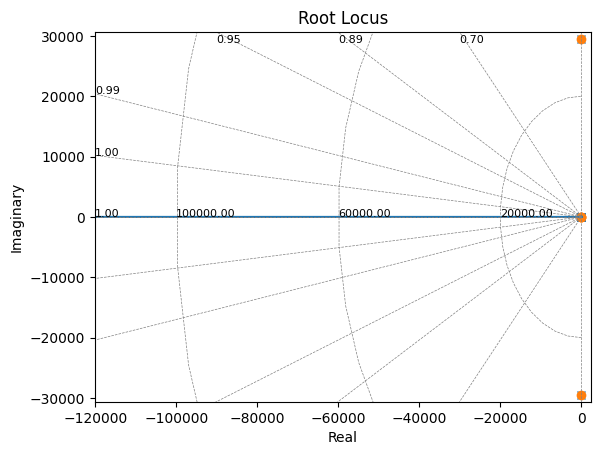

In [112]:
ct.root_locus(P_tf)

C:\Users\bpele\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\linalg\_basic.py:1679: RuntimeWarning: invalid value encountered in cast
  ps = ps.astype(int, copy=False) - 1
C:\Users\bpele\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\linalg\_matfuncs.py:377: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
C:\Users\bpele\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\linalg\_matfuncs.py:377: RuntimeWarning: invalid value encountered in matmul
  eAw = eAw @ eAw


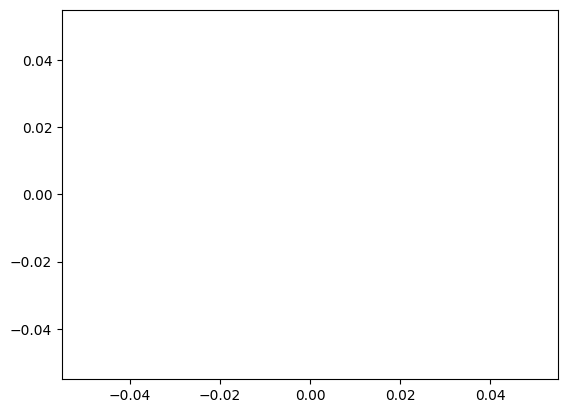

In [113]:
K_unity = 1
L = K_unity * P_tf
T = L / (1+L)

t, y = ct.step_response(T)
plt.plot(t, y)

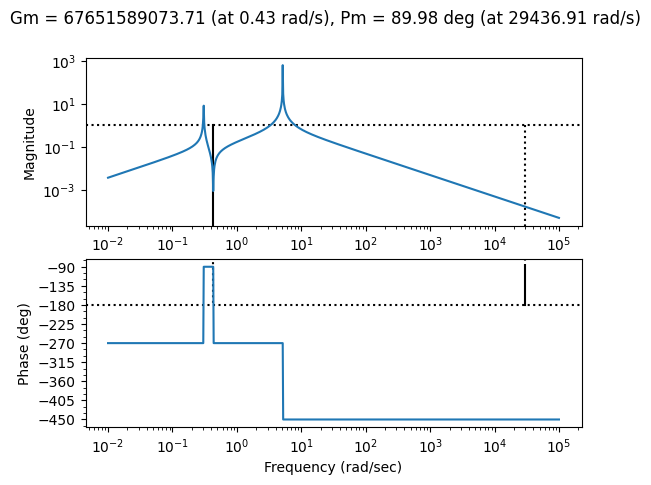

In [114]:
mag, phase, omega = ct.bode_plot(P_tf, margins=True)

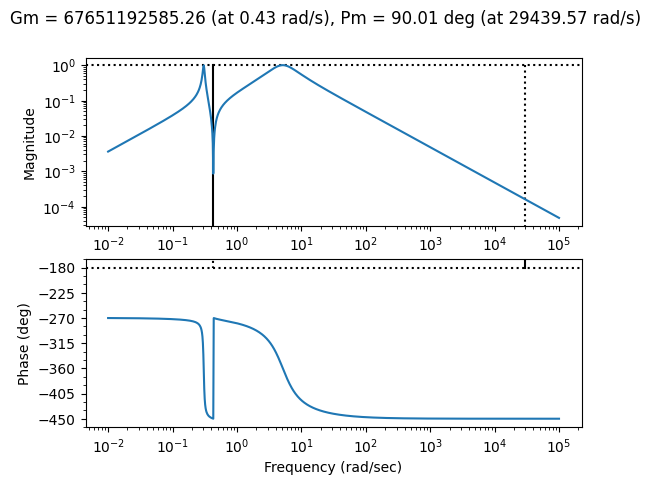

In [115]:
mag, phase, omega = ct.bode_plot(T, margins=True)

(array([[-2.38095246e+00-4.56073542e+00j, -2.38095246e+00+4.56073542e+00j,
         -8.33325762e-03-3.05174132e-01j, ...,
          1.16504029e-14+5.15256113e+00j,  7.49961373e-08-2.94369136e+04j,
          7.49961373e-08+2.94369136e+04j],
        [-2.45838470e+00-4.51888508e+00j, -2.45838470e+00+4.51888508e+00j,
         -8.60425726e-03-3.05196988e-01j, ...,
         -3.68594044e-14+5.15256113e+00j,  5.63369440e-08-2.94369138e+04j,
          5.63369440e-08+2.94369138e+04j],
        [-2.53581695e+00-4.47528515e+00j, -2.53581695e+00+4.47528515e+00j,
         -8.87525511e-03-3.05220585e-01j, ...,
          1.47659662e-14+5.15256113e+00j,  1.08723270e-08-2.94369139e+04j,
          1.08723270e-08+2.94369139e+04j],
        ...,
        [-1.17748135e+06+0.00000000e+00j, -1.13130912e-05+0.00000000e+00j,
         -5.57786404e-06-4.30341752e-01j, ...,
         -4.86806775e-17+5.15256113e+00j, -2.16927629e-06-2.94369126e+04j,
         -2.16927629e-06+2.94369126e+04j],
        [-1.17747705e+07+0.

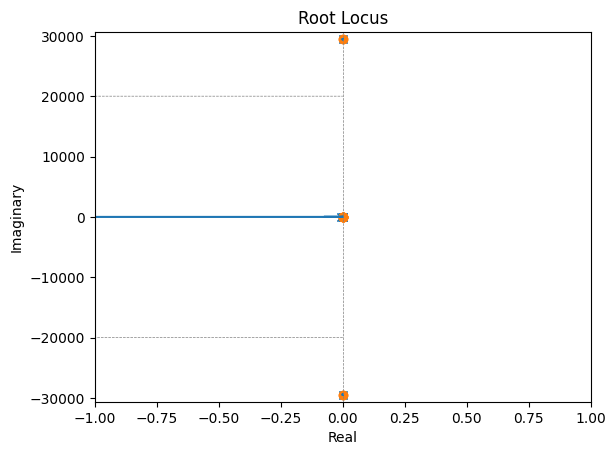

In [116]:
ct.root_locus(T, xlim=[-1, 1])

needs a better gain margin and a phase margin, lets find the poles and zeros

In [118]:
poles = ct.poles(P_tf)
zeroes = ct.zeros(P_tf)

print("Poles: ", poles)
print("Zeroes: ", zeroes)

Poles:  [ 2.72848411e-12+2.94369135e+04j  2.72848411e-12-2.94369135e+04j
 -3.72309539e-64+5.15256113e+00j -3.72309539e-64-5.15256113e+00j
  3.96895643e-30+3.04829627e-01j  3.96895643e-30-3.04829627e-01j]
Zeroes:  [-1.12258856e-07+2.94369135e+04j -1.12258856e-07-2.94369135e+04j
  2.03164182e-11+4.30341753e-01j  2.03164182e-11-4.30341753e-01j
 -4.26586169e-11+0.00000000e+00j]


Let's cancel the unstable poles with 2 PID controllers, adding third pole at 0.001 for proper TF

C:\Users\bpele\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\timeresp.py:1051: RuntimeWarning: invalid value encountered in subtract
  Bd0 = expM[:n_states, n_states:n_states + n_inputs] - Bd1
C:\Users\bpele\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\timeresp.py:1054: RuntimeWarning: invalid value encountered in matmul
  xout[:, i] = (Ad @ xout[:, i-1]


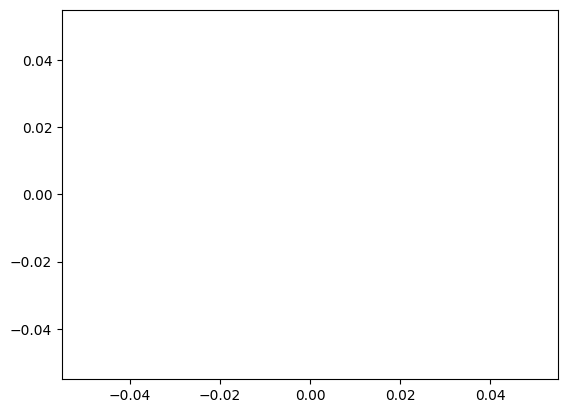

In [119]:
Kp = 30
L = Kp*P_tf
T = L / (1+L)

t, y = ct.step_response(T)
plt.plot(t, y)

make root locus


(array([[-1.43172355e+02+0.00000000e+00j, -9.74574445e-02+0.00000000e+00j,
         -4.36651429e-02-4.18204576e-01j, -4.36651429e-02+4.18204576e-01j,
         -3.67160173e-04-2.94369135e+04j, -3.67160173e-04+2.94369135e+04j,
         -7.77156117e-16-5.15256113e+00j, -7.77156117e-16+5.15256113e+00j,
          2.21142549e-14-3.04829627e-01j,  2.21142549e-14+3.04829627e-01j,
          3.67160127e-04-2.94369135e+04j,  3.67160127e-04+2.94369135e+04j],
        [-1.43172355e+02+0.00000000e+00j, -9.74574445e-02+0.00000000e+00j,
         -4.36651429e-02-4.18204576e-01j, -4.36651429e-02+4.18204576e-01j,
         -3.67160173e-04-2.94369135e+04j, -3.67160173e-04+2.94369135e+04j,
         -7.77156117e-16-5.15256113e+00j, -7.77156117e-16+5.15256113e+00j,
          2.21142549e-14-3.04829627e-01j,  2.21142549e-14+3.04829627e-01j,
          3.67160127e-04-2.94369135e+04j,  3.67160127e-04+2.94369135e+04j],
        [-2.54638863e+03+0.00000000e+00j, -5.23204430e-03+0.00000000e+00j,
         -2.57890618e-0

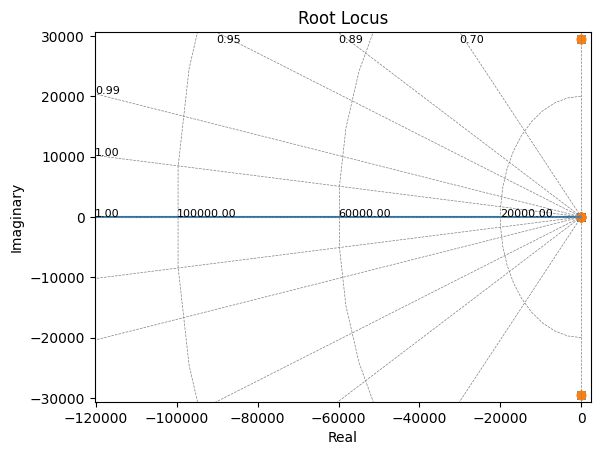

In [120]:
ct.root_locus(T)